# B-Tree in Python #
B-tree is a special type of self-balancing search tree in which each node can contain more than one key and can have more than two children. 

## Why do you need a B-tree data structure? ##

The need for B-tree arose with the rise in the need for lesser time in accessing physical storage media like a hard disk.

The secondary storage devices are slower with a larger capacity.

There was a need for such types of data structures that minimize the disk access.

However, B-tree can store many keys in a single node and can have multiple child nodes.

This decreases the height significantly allowing faster disk accesses.

## What Is a B-Tree Data Structure? ##

A B-tree is a self-balanced tree data structure that is a generalized form of the Binary Search Tree (BST).

However, unlike a binary tree, each node can have more than two children.

In other words, each node can have up to m children and $ m-1 $ keys; also, each node must have at least children to keep the tree balanced.

These features keep the tree’s height relatively small.

A B-tree data structure keeps the data sorted and allows searching, inserting, and deleting operations performed in amortized logarithmic time.

To be more specific, the time complexity for accomplishing the mentioned operations is , where n is the number of keys stored in the tree.

The B-Tree data structure tries to minimize the number of disk access using advanced techniques and optimized algorithms for searching, inserting, and deleting, all of which llow the B-tree to stay balanced and, therefore, ensure finding data in logarithmic time.

![B-Tree Data Structure.jpg](B-Tree%20Data%20Structure.jpg)
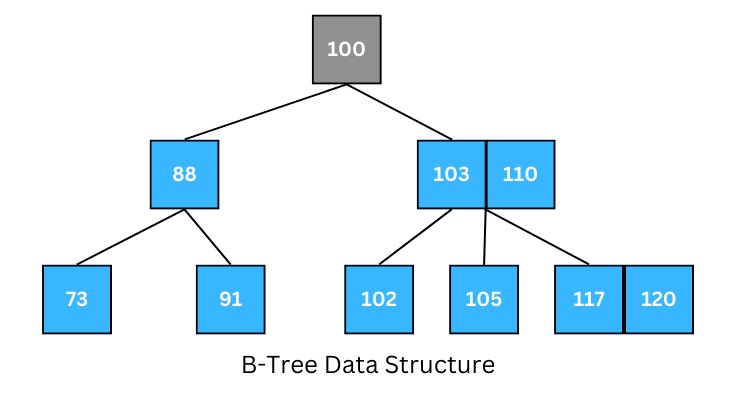

## B-Tree Properties ##

There are three types of nodes in a B-tree of order m, and each of them has the following properties:

- Root Node
    - A root node has between 2 and $m$ children.<br>
      <br>
- Internal Nodes
    - Each internal node has between $ [\frac{m}{2}] $ and $m$ children — both ends are included.
    - Each internal node may contain up to $m - 1$ keys.<br>
      <br>
- Leaf Nodes
    - All leaf nodes are at the same level.
    - Each leaf node stores between $[ \frac{m-1}{2} ]$ and $ m - 1 $ keys — both ends are included.<br>
      <br>
- The height of a B-Tree can be yielded via the following equation:<br>
    - $ h \leq \log_m \frac{n + 1}{2} $ , where m is the minimum degree and n is the number of keys.


![b-tree level.jpg](b-tree%20level.jpg)

## Key B-Tree Mathematical Formulas ##

B-tree mathematical formulas define the height, maximum keys, and node capacity based on order $ (m) $ or minimum degree $ (t) $.

The tree height $ (h) $ is $ O(\log_t n) $, with maximum keys $ k \leq m^{h+1} - 1$ and minimum keys $ 2t^{h-1} - 1 $, ensuring logarithmic search time.

### Mathematical formulas ###

* Order $(m)$: Max children per node.
* Minimum degree $(t)$: Minimum children (except root), where $ t = [\frac{m}{2}]$.
* Max keys in node: $ m -1 $.
* Min keys in node: $ t - 1 $ (except root).
* Max Height $ (h_{max}) $: $[ \log_t (\frac{n+1}{2}) ]$, where $n$ is total keys.
* Min Height $ (h_{min}) $: $[ \log_m(n+1) ]  - 1$.
* Max Total Keys: $ m^{h+1} - 1 $.

Exam:

B-tree of order $m = 20$ ($min$ degree $t = 10$) with height $h = 2$ can hold a maximum of $ 20^{2+1} - 1$ keys (Max Total Keys).

### The various properties of B trees include: ###

* Every node in a B-Tree will hold a maximum of m children and $ (m - 2) $ keys, since the order of the tree is m.
* Every node in a B-Tree, except root and leaf, can hold at least $ m/2 $ children
* The root node must have no less than two children.
* All the paths in a B-Tree must end at the same level, i.e. the leaf nodes must be at the same level.
* A B-tree always maintains sorted data.

## Basic Operations of B Trees ##

The operations supported in B trees are Insertion, deletion and searching with the time complexity of $ 0(\log n) $ for every operation.

B-Trees support various operations that make them highly efficient for managing large datasets.<br>

Below are the key operations:

| Operation |     Time Complexity     |
|:---------:|:-----------------------:|
|  Search   | $ O(log \thinspace n) $ |
|  Insert   | $ O(log \thinspace n) $ |
|  Delete   | $ O(log \thinspace n) $ |
| Traverse  |        $ O(n) $         |

**Note** "n" is the total number of elements in the B-tree.

### Traversal of B-Tree

Let us see how we can define a class for the B tree in Python.<br>
Let us see the individual parts of code used for the implementation of the B tree.

#### Step by step: how to work traversal?

* Create a node with the name **BTreeNode** to create a default node with a list of keys and a list of children nodes.
* The b-tree class will be created which has two attributes **root** and **t**, root represents the root node, and **t** represents the minimum degree of the B-tree.
* The display function in class **Btree** will be used to print to nodes of the tree in level-wise format.
* The final tree is created in the main function by inserting keys in the B-tree.

#### Implementation of code  ####

Following are the implementations of this operation in Python:

In [10]:
class BTreeNode:
    def __init__(self, leaf=True):
        self.leaf = leaf
        self.keys = []
        self.children = []

    def display(self, level=0):
        print(f"Level {level}: {self.keys}")
        if not self.leaf:
            for child in self.children:
                child.display(level + 1)


class BTree:
    def __init__(self, t):
        self.root = BTreeNode(True)
        self.t = t

    def display(self):
        self.root.display()

    def insert(self, k):
        root = self.root
        if len(root.keys) == (2 * self.t) - 1:
            temp = BTreeNode()
            self.root = temp
            temp.children.append(root)
            self.split_child(temp, 0)
            self.insert_non_full(temp, k)
        else:
            self.insert_non_full(root, k)

    def insert_non_full(self, x, k):
        i = len(x.keys) - 1
        if x.leaf:
            x.keys.append(None)  # Make space for the new key
            while i >= 0 and k < x.keys[i]:
                x.keys[i + 1] = x.keys[i]
                i -= 1
            x.keys[i + 1] = k
        else:
            while i >= 0 and k < x.keys[i]:
                i -= 1
            i += 1
            if len(x.children[i].keys) == (2 * self.t) - 1:
                self.split_child(x, i)
                if k > x.keys[i]:
                    i += 1
            self.insert_non_full(x.children[i], k)

    def split_child(self, x, i):
        t = self.t
        y = x.children[i]
        z = BTreeNode(leaf=y.leaf)
        x.keys.insert(i, y.keys[t - 1])
        z.keys = y.keys[t: (2 * t) - 1]
        y.keys = y.keys[0: t - 1]
        if not y.leaf:
            z.children = y.children[t: 2 * t]
            y.children = y.children[0: t - 1]
        x.children.insert(i + 1, z)


def main():
    B = BTree(3)

    keys = [10, 20, 5, 6, 12, 30, 7, 17]
    for key in keys:
        B.insert(key)

    print("B-tree structure:")
    B.display()


if __name__ == '__main__':
    main()

B-tree structure:
Level 0: [7, 10, 17, 30]


### Search operation in B Tree

B tree makes it convenient for users to search for an element in it like searching for an element in any other binary tree.<br>
Let us see how it searches for an element $ m $ in the tree.

#### Step by step: how to work search?

* m is not found in the root so we will compare it with the key. i.e. compare 10 and 100.
* Since $ 10 < 100 $, we will search in the left part of the tree.
* Now we will compare m with all the elements in the current node i.e. we will compare m with 35 and 65 in order.
* Since m is smaller than both 35 and 65, we will go to the left side of the tree to find the element.
* Now we will compare m with all the keys of the current node i.e. 10 and 20 but the first key of this node is equal to m so we found the element.

Time Complexity : $O(\log n)$

#### Implementation of code  ####

Following are the implementations of this operation in Python:

In [14]:
# Create a node
class BTreeNode:
  def __init__(self, leaf=False):
    self.leaf = leaf
    self.keys = []
    self.child = []


# Tree
class BTree:
  def __init__(self, t):
    self.root = BTreeNode(True)
    self.t = t

    # Insert node
  def insert(self, k):
    root = self.root
    if len(root.keys) == (2 * self.t) - 1:
      temp = BTreeNode()
      self.root = temp
      temp.child.insert(0, root)
      self.split_child(temp, 0)
      self.insert_non_full(temp, k)
    else:
      self.insert_non_full(root, k)

    # Insert nonfull
  def insert_non_full(self, x, k):
    i = len(x.keys) - 1
    if x.leaf:
      x.keys.append((None, None))
      while i >= 0 and k[0] < x.keys[i][0]:
        x.keys[i + 1] = x.keys[i]
        i -= 1
      x.keys[i + 1] = k
    else:
      while i >= 0 and k[0] < x.keys[i][0]:
        i -= 1
      i += 1
      if len(x.child[i].keys) == (2 * self.t) - 1:
        self.split_child(x, i)
        if k[0] > x.keys[i][0]:
          i += 1
      self.insert_non_full(x.child[i], k)

    # Split the child
  def split_child(self, x, i):
    t = self.t
    y = x.child[i]
    z = BTreeNode(y.leaf)
    x.child.insert(i + 1, z)
    x.keys.insert(i, y.keys[t - 1])
    z.keys = y.keys[t: (2 * t) - 1]
    y.keys = y.keys[0: t - 1]
    if not y.leaf:
      z.child = y.child[t: 2 * t]
      y.child = y.child[0: t - 1]

  # Print the tree
  def print_tree(self, x, l=0):
    print("Level ", l, " ", len(x.keys), end=":")
    for i in x.keys:
      print(i, end=" ")
    print()
    l += 1
    if len(x.child) > 0:
      for i in x.child:
        self.print_tree(i, l)

  # Search key in the tree
  def search_key(self, k, x=None):
    if x is not None:
      i = 0
      while i < len(x.keys) and k > x.keys[i][0]:
        i += 1
      if i < len(x.keys) and k == x.keys[i][0]:
        return (x, i)
      elif x.leaf:
        return None
      else:
        return self.search_key(k, x.child[i])

    else:
      return self.search_key(k, self.root)


def main():
  B = BTree(3)

  for i in range(20):
    B.insert((i, 2 * i))

  B.print_tree(B.root)

  if B.search_key(12) is not None:
    print("\nFound")
  else:
    print("\nNot Found")


if __name__ == '__main__':
  main()

Level  0   1:(8, 16) 
Level  1   2:(2, 4) (5, 10) 
Level  2   2:(0, 0) (1, 2) 
Level  2   2:(3, 6) (4, 8) 
Level  1   2:(11, 22) (14, 28) 
Level  2   2:(9, 18) (10, 20) 
Level  2   2:(12, 24) (13, 26) 
Level  2   5:(15, 30) (16, 32) (17, 34) (18, 36) (19, 38) 

Found


### Insert operation ###

The insertion operation for a B Tree is the elements are inserted into the same node until the maximum keys are reached.

The insertion is done using the following procedure:

#### First Step ####
Calculate the maximum $ (m - 1) $ and, minimum $ ([\frac{m}{2}] - 1 ) $ number of keys a node can hold, where $ m $ is denoted by the order of the B-Tree.

Insert <span style="color:green"> **(5, 3, 21, 9, 13, 22, 7, 10, 11, 14, 8, 16)**</span> into a B-Tree.

* Order $(m) = 4$
* Maximum keys $ (m - 1) = 3$
* Minimum keys $ ([\frac{m}{2}]) - 1 = 1$
* Maximum children $= 4$
* Minimum children $([\frac{m}{2}]) = 2$

#### Second Step ####
The data is inserted into the tree using the binary search insertion and once the keys reach the maximum number, the node is split into half and the median key becomes the internal node while the left and right keys become its children.

Insert <span style="color:green"> **(5, 3, 21, 9, 13, 22, 7, 10, 11, 14, 8, 16)**</span> into a B-Tree.

![data inserted.jpg](data_inserted.jpg)

#### Third Step ####
All the leaf nodes must be on the same level.

Insert <span style="color:green"> **(5, 3, 21, 9, 13, 22, 7, 10, 11, 14, 8, 16)**</span> into a B-Tree.

![leaf nodes same level](leaf_nodes_same_level.jpg)


The keys, 5, 3, 21, 9, 13 are all added into the node according to the binary search property but if we add the key 22, it will violate the maximum key property. Hence, the node is split in half, the median key is shifted to the parent node and the insertion is then continued.


![adding key 11](adding_key_11.jpg)


Another hiccup occurs during the insertion of 11, so the node is split and median is shifted to the parent.


![adding key 16](adding_key_16.jpg)


While inserting 16, even if the node is split in two parts, the parent node also overflows as it reached the maximum keys. Hence, the parent node is split first and the median key becomes the root. Then, the leaf node is split in half the median of leaf node is shifted to its parent.


![final b-tree](final_B_tree.jpg)

#### Implementation of code  ####

Following are the implementations of this operation in Python:

In [15]:
# Define a class called Node to represent a node in a binary search tree
class BTreeNode:
    # Initialize the Node object with a value, and set the left and right child pointers to None
    def __init__(self, value):
        #node declaration
        self.value = value
        self.left = None
        self.right = None

    # Define a custom __str__ method to convert the node's value to a string
    def __str__(self):
        return str(self.value)

# Define a class called BinarySearchTree to represent a Binary Search Tree
class BinarySearchTree:
    # Initialize the BST with an empty root node
    def __init__(self):
        self.root = None

    # Insert a value into the Binary Search Tree (BST)
    def insert(self, value):
        # If the root is None, create a new node with the given value as the root
        if self.root is None:
            self.root = BTreeNode(value)
        else:
            self._insert_recursive(self.root, value)

    # Helper method to recursively insert a value into the BST
    def _insert_recursive(self, node, value):
        if value < node.value:
            if node.left is None:
                node.left = BTreeNode(value)
            else:
                self._insert_recursive(node.left, value)
        elif value > node.value:
            if node.right is None:
                node.right = BTreeNode(value)
            else:
                self._insert_recursive(node.right, value)

    # Search for a value in the BST
    def search(self, value):
        return self._search_recursive(self.root, value)

    # Helper method to recursively search for a value in the BST and return the node if found
    def _search_recursive(self, node, value):
        if node is None or node.value == value:
            return node
        if value < node.value:
            return self._search_recursive(node.left, value)
        else:
            return self._search_recursive(node.right, value)


# Example
# Create instance of BinarySearchTree
bst = BinarySearchTree()

# Insert values into the BST
bst.insert(1)
bst.insert(2)
bst.insert(3)
bst.insert(4)
bst.insert(5)
bst.insert(6)
bst.insert(7)
bst.insert(8)
bst.insert(9)
bst.insert(10)
bst.insert(11)

# Search for elements in the BST and print the results
print("Searching for elements\n")
print(bst.search(1), "\n")
print(bst.search(5), "\n")
print(bst.search(8), "\n")
print(bst.search(11), "\n")
print(bst.search(15))  # This value is not in B-tree

Searching for elements

1 

5 

8 

11 

None


### Delete operation ###
The deletion operation in a B tree is slightly different from the deletion operation of a Binary Search Tree.

The procedure to delete a node from a B tree is as follows.

Deleting an element on a B-tree consists of three main events:

* searching the node where the key to be deleted exists
* deleting the key
* balancing the tree if required

While deleting a tree, a condition called underflow may occur.

Underflow occurs when a node contains less than the minimum number of keys it should hold.

The terms to be understood before studying deletion operation are:

* Inorder Predecessor:<br>
    The largest key on the left child of a node is called its inorder predecessor.

* Inorder Successor:<br>
    The smallest key on the right child of a node is called its inorder successor.

#### Case Delete Key 14 ####

If the key to be deleted is in a leaf node and the deletion does not violate the minimum key property, just delete the node.

<b>Delete key 14</b>

![delete_key_14.jpg](delete_key_14.jpg)

<b>Deleted key 14</b>

![deleted_key_14.jpg](deleted_key_14.jpg)

#### Case Delete Key 3 ####

If the key to be deleted is in a leaf node but the deletion violates the minimum key property, borrow a key from either its left sibling or right sibling. In case if both siblings have exact minimum number of keys, merge the node in either of them.

<b>Delete key 3</b><br>

![delete_key_3.jpg](delete_key_3.jpg)

<b>Deleted key 3</b><br>

![deleted_key_3.jpg](deleted_key_3.jpg)

#### Case Delete Key 13 ####
If the key to be deleted is in an internal node, it is replaced by a key in either left child or right child based on which child has more keys. But if both child nodes have minimum number of keys, they are merged together.

<b>Delete key 13</b>

![delete_key_13.jpg](delete_key_13.jpg)

<b>Deleted key 3</b>

![deleted_key_13.jpg](deleted_key_13.jpg)

#### Case Delete Key 5 ####
If the key to be deleted is in an internal node violating the minimum keys property, and both its children and sibling have minimum number of keys, merge the children. Then merge its sibling with its parent.

<b>Delete key 5</b>

![delete_key_5.jpg](delete_key_5.jpg)

<b>Deleted key 5</b>

![deleted_key_5.jpg](deleted_key_5.jpg)

#### Implementation of code  ####

Following are the implementations of this operation in Python:

In [17]:
# Create BTree Node
class BTreeNode:
    def __init__(self, t, leaf):
        self.keys = [0] * (2*t-1)
        self.t = t
        self.leaf = leaf
        self.n = 0
        self.C = [None] * (2*t)

    def findKey(self, k):
        idx = 0
        while idx < self.n and self.keys[idx] < k:
            idx += 1
        return idx

    # Splits the child y of this node. y must be full (2t-1 keys)
    def splitChild(self, i, y):
        z = BTreeNode(y.t, y.leaf)
        z.n = self.t - 1
        for j in range(self.t-1):
            z.keys[j] = y.keys[j + self.t]
        if not y.leaf:
            for j in range(self.t):
                z.C[j] = y.C[j + self.t]
        y.n = self.t - 1
        for j in range(self.n, i, -1):
            self.C[j+1] = self.C[j]
        self.C[i+1] = z
        for j in range(self.n-1, i-1, -1):
            self.keys[j+1] = self.keys[j]
        self.keys[i] = y.keys[self.t-1]
        self.n += 1

    def insertNonFull(self, k):
        i = self.n - 1
        if self.leaf:
            while i >= 0 and self.keys[i] > k:
                self.keys[i+1] = self.keys[i]
                i -= 1
            self.keys[i+1] = k
            self.n += 1
        else:
            while i >= 0 and self.keys[i] > k:
                i -= 1
            if self.C[i+1].n == 2*self.t-1:
                self.splitChild(i+1, self.C[i+1])
                if self.keys[i+1] < k:
                    i += 1
            self.C[i+1].insertNonFull(k)

    # Rebalances child C[idx] if it has fewer than t-1 keys
    def fill(self, idx):
        if idx!= 0 and self.C[idx-1].n >= self.t:
            child = self.C[idx]
            sib = self.C[idx-1]
            for j in range(child.n-1, -1, -1):
                child.keys[j+1] = child.keys[j]
            if not child.leaf:
                for j in range(child.n):
                    child.C[j+1] = child.C[j]
            child.keys[0] = self.keys[idx-1]
            if not child.leaf:
                child.C[0] = sib.C[sib.n]
            self.keys[idx-1] = sib.keys[sib.n-1]
            child.n += 1
            sib.n -= 1
        elif idx!= self.n and self.C[idx+1].n >= self.t:
            child = self.C[idx]
            sib = self.C[idx+1]
            child.keys[child.n] = self.keys[idx]
            if not child.leaf:
                child.C[child.n+1] = sib.C[0]
            self.keys[idx] = sib.keys[0]
            for j in range(sib.n-1):
                sib.keys[j] = sib.keys[j+1]
            if not sib.leaf:
                for j in range(sib.n):
                    sib.C[j] = sib.C[j+1]
            child.n += 1
            sib.n -= 1
        else:
            i = idx if idx!= self.n else idx-1
            child = self.C[i]
            sib = self.C[i+1]
            child.keys[self.t-1] = self.keys[i]
            for j in range(sib.n):
                child.keys[self.t + j] = sib.keys[j]
            if not child.leaf:
                for j in range(sib.n+1):
                    child.C[self.t + j] = sib.C[j]
            for j in range(self.n-i-2):
                self.keys[i + j] = self.keys[i + j + 1]
            for j in range(self.n-i-1):
                self.C[i + j] = self.C[i + j + 1]
            child.n += sib.n + 1
            self.n -= 1

    def remove(self, k):
        idx = self.findKey(k)
        if idx < self.n and self.keys[idx] == k:
            if self.leaf:
                for j in range(idx, self.n-1):
                    self.keys[j] = self.keys[j+1]
                self.n -= 1
            else:
                if self.C[idx].n >= self.t:
                    cur = self.C[idx]
                    while not cur.leaf:
                        cur = cur.C[cur.n]
                    pred = cur.keys[cur.n-1]
                    self.keys[idx] = pred
                    self.C[idx].remove(pred)
                elif self.C[idx+1].n >= self.t:
                    cur = self.C[idx+1]
                    while not cur.leaf:
                        cur = cur.C[0]
                    succ = cur.keys[0]
                    self.keys[idx] = succ
                    self.C[idx+1].remove(succ)
                else:
                    self.fill(idx)
                    self.remove(k)
        else:
            if self.leaf:
                return
            flag = (idx == self.n)
            if self.C[idx].n < self.t:
                self.fill(idx)
            if flag and idx > self.n:
                self.C[idx-1].remove(k)
            else:
                self.C[idx].remove(k)

    def traverse(self):
        for i in range(self.n):
            if not self.leaf:
                self.C[i].traverse()
            print(" {}".format(self.keys[i]), end='')
        if not self.leaf:
            self.C[self.n].traverse()

class BTree:
    def __init__(self, t):
        self.root = None
        self.t = t

    def insert(self, k):
        if self.root is None:
            self.root = BTreeNode(self.t, True)
            self.root.keys[0] = k
            self.root.n = 1
        else:
            if self.root.n == 2*self.t-1:
                s = BTreeNode(self.t, False)
                s.C[0] = self.root
                s.splitChild(0, self.root)
                i = 1 if s.keys[0] < k else 0
                s.C[i].insertNonFull(k)
                self.root = s
            else:
                self.root.insertNonFull(k)

    def remove(self, k):
        if self.root is None:
            return
        self.root.remove(k)
        if self.root.n == 0:
            self.root = None if self.root.leaf else self.root.C[0]

    def traverse(self):
        if self.root is not None:
            self.root.traverse()
        print()

if __name__ == '__main__':
    tree = BTree(3)
    tree.insert(10)
    tree.insert(333)
    tree.insert(5)
    tree.insert(15)
    tree.insert(2)
    tree.insert(7)
    tree.insert(12)
    tree.insert(20)
    tree.insert(33)
    tree.insert(19)
    tree.insert(22)
    tree.insert(71)
    tree.insert(111)
    tree.insert(29)
    print('Tree traversal:', end='')
    tree.traverse()
    tree.remove(5)
    tree.remove(12)
    tree.remove(22)
    tree.remove(29)
    print('After removing:', end='')
    tree.traverse()

Tree traversal: 2 5 7 10 12 15 19 20 22 29 33 71 111 333
After removing: 2 7 10 15 19 20 33 71 111 333


## Sources:

[tutorialspoint.com](https://www.tutorialspoint.com/data_structures_algorithms/b_trees.htm)

[geeksforgeeks.org](https://www.geeksforgeeks.org/dsa/b-tree-in-python/)

[programiz.com](https://www.programiz.com/dsa/b-tree)